In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("Midterm_53_group.csv")

# Create 1-second buckets
df["Time"] = df["Time"].astype(float)
df["Second"] = df["Time"].astype(int)

# Count packets per second
traffic = df.groupby("Second").size().reset_index(name="Packets")

print(traffic.head())

   Second  Packets
0       0        2
1       1        1
2       2        1
3       3        1
4       8        1


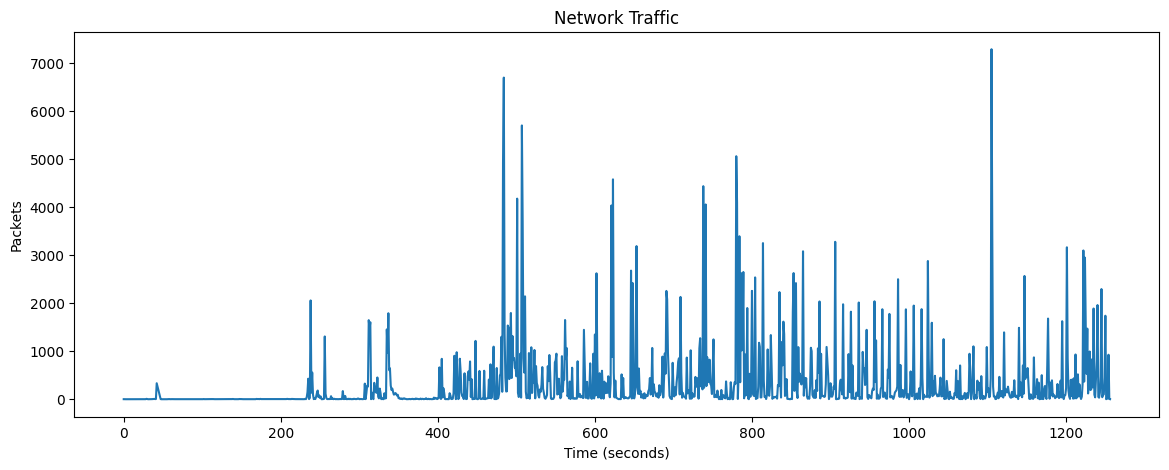

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(traffic["Second"], traffic["Packets"])
plt.title("Network Traffic")
plt.xlabel("Time (seconds)")
plt.ylabel("Packets")
plt.show()

In [8]:
train = traffic.iloc[:int(len(traffic)*0.8)]
test = traffic.iloc[int(len(traffic)*0.8):]

In [9]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["Packets"], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Packets   No. Observations:                  984
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -7808.216
Date:                Thu, 06 Aug 2026   AIC                          15628.432
Time:                        23:49:54   BIC                          15657.776
Sample:                             0   HQIC                         15639.594
                                - 984                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6784      0.014    -49.178      0.000      -0.705      -0.651
ar.L2         -0.5310      0.019    -28.201      0.000      -0.568      -0.494
ar.L3         -0.3582      0.021    -17.206      0.0

In [10]:
forecast = model_fit.forecast(steps=len(test))

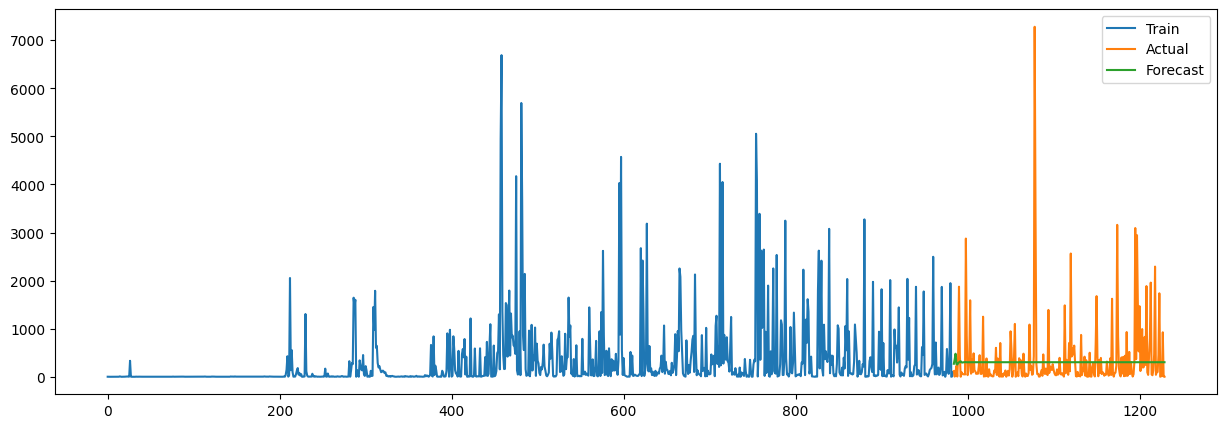

In [11]:
plt.figure(figsize=(15,5))

plt.plot(train.index, train["Packets"], label="Train")
plt.plot(test.index, test["Packets"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.show()

In [12]:
threshold = traffic["Packets"].mean() + 3*traffic["Packets"].std()

alerts = forecast[forecast > threshold]

print(alerts)

Series([], Name: predicted_mean, dtype: float64)


In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Packets"], forecast)
rmse = np.sqrt(mean_squared_error(test["Packets"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 382.0286073169294
RMSE: 738.126317911017
